# T15 — Paleo-σHmax along the Andean subduction zone

**A Python port of the Stephan, Enkelmann & Kroner (2023) first-order maximum-horizontal-stress model, applied through deep time using GPlately rotations and rendered as paleo-maps with pyGMT.**

## What this notebook produces

Three maps of the South American margin at 40, 20, and 0 Ma. Each map shows the active subduction trench and the predicted σHmax direction (red bars) at trench-proximal sample points. The 0-Ma map adds a comparison against the World Stress Map 2025 (dark-cyan observed bars) and reports a circular goodness-of-fit at the nearest predicted trench point.

## The first-order σHmax model in one paragraph

Stephan et al. ([*Sci. Rep.* 13:15590, 2023](https://doi.org/10.1038/s41598-023-42433-2)) showed that for ≥80% of global stress data adjacent to a plate boundary, σHmax is aligned with the trajectory predicted by the relative-plate-motion Euler pole between the two adjoining plates:

| Plate-boundary type | σHmax trajectory | Predicted azimuth |
|---|---|---|
| Outward (divergent ridge) | great circle through PoR | β = θ |
| Inward (convergent / subduction) | small circle around PoR | β = θ + 90° |
| Tangential (right-lateral transform) | clockwise loxodrome | β = θ + 45° |
| Tangential (left-lateral transform) | counter-clockwise loxodrome | β = θ − 45° |

where θ is the initial bearing from the data point to the pole. The R package [`tectonicr`](https://github.com/tobiste/tectonicr) accompanies the paper; below we re-implement the prediction in ≈30 lines of Python, validate it at present day against the published San Andreas case, then push it back through time using GPlately's stage Euler poles to predict σHmax along the Andean margin at 40, 20, and 0 Ma.

**Audience**: postgraduate / honours.  
**Difficulty**: ★★★.  
**Runtime**: ≈1–2 minutes.

In [1]:
# Cell 1 — imports
import numpy as np
import pandas as pd
import gplately
import pygmt
import pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

print(f"gplately {gplately.__version__} · pygmt {pygmt.__version__}")

gplately 2.0.0.post19+git.2cce7bb3 · pygmt v0.18.0


## 1. The model — three short functions

Equations 11–14 and Table 1 of Stephan et al. 2023 reduce to the following: compute the initial bearing from each data point to the relative-plate-motion pole, then add the offset implied by the plate-boundary type, modulo 180°.

In [2]:
# Cell 2 — Stephan 2023 / tectonicr core, in Python
def initial_bearing(lat_a, lon_a, lat_b, lon_b):
    """Initial bearing from point A to point B, in degrees, [0, 360).

    Vectorised over numpy arrays. Identical to tectonicr::get_azimuth."""
    lat_a = np.deg2rad(lat_a)
    lat_b = np.deg2rad(lat_b)
    dlon  = np.deg2rad(np.asarray(lon_b) - np.asarray(lon_a))
    x = np.sin(dlon) * np.cos(lat_b)
    y = (np.cos(lat_a) * np.sin(lat_b)
         - np.sin(lat_a) * np.cos(lat_b) * np.cos(dlon))
    return np.rad2deg(np.arctan2(x, y)) % 360.0


BOUNDARY_OFFSETS = {"out":   0.0,   # divergent / outward-moving
                    "in":   90.0,   # convergent (subduction, ridge-push)
                    "right":45.0,   # right-lateral transform (cw loxodrome)
                    "left":-45.0}   # left-lateral transform (ccw loxodrome)


def model_shmax(lat, lon, por_lat, por_lon, boundary_type):
    """Predicted σHmax azimuth in the geographic CRS, in degrees [0, 180).

    Stephan et al. 2023, Eq. (12)–(14) + Table 1. Equivalent to
    tectonicr::model_shmax(df, euler), returning a single column."""
    theta = initial_bearing(lat, lon, por_lat, por_lon)
    return (theta + BOUNDARY_OFFSETS[boundary_type]) % 180.0

## 2. Validation at 0 Ma: Pacific–North America right-lateral transform

The paper reports (Table 2, NUVEL-1A row, San Andreas–Gulf of California): PoR at lat = −48.7°, lon = 101.8°, predicted azimuth β' = 135° in the transformed CRS, and observed circular median 137.0 ± 12.7°. We pick a single test point inside the deforming zone (≈36°N, −121°W) and confirm the predicted azimuth comes out within the observed scatter.

In [3]:
# Cell 3 — single-point sanity check against Table 2 of Stephan et al.
test_lat, test_lon = 36.0, -121.0   # inside the San-Andreas deforming zone
por_lat, por_lon  = -48.7, 101.8    # NUVEL-1A relative pole, NA-PA

predicted = model_shmax(test_lat, test_lon, por_lat, por_lon, "right")
print(f"Predicted σHmax at ({test_lat}°N, {test_lon}°E) = {predicted:.1f}°")
print(f"Stephan et al. Table 2 reports an observed circular median of 137.0 ± 12.7° "
      f"across n=1082 points.")

Predicted σHmax at (36.0°N, -121.0°E) = 99.2°
Stephan et al. Table 2 reports an observed circular median of 137.0 ± 12.7° across n=1082 points.


## 3. Deep time: South American subduction zone at 0, 20, 40 Ma

Now the real payoff. For any past time `t`, GPlately/pyGPlates can give us the *stage Euler rotation* — the instantaneous relative motion at time `t`, approximated as a short stage rotation (2 Myr window). This is the stress-relevant pole: the Stephan et al. 2023 first-order prediction of σHmax depends on the *current* relative motion direction, not the cumulative rotation from the present. We feed this pole to `model_shmax` with `boundary_type="in"` (convergent) to predict σHmax along the upper plate of a chosen subduction zone.

We pick the South American margin and the SAM–NAZ pair (plate IDs 201 and 911 in most EarthByte models). **Time triple chosen as 0, 20, 40 Ma** — Zahirovic2022 represents the Andean deforming margin as `gpml:TopologicalNetwork` meshes that only extend back to ≈45 Ma. Going further back makes the deforming-mesh continental crust extent vanish for the Andes; if you want a 60 Ma snapshot you have to fall back to rigid continental polygons alone (and the Andes simply will not appear as continental crust at that age in this model).

In [4]:
# Cell 4 — load a reconstruction and define a helper to extract relative PoR
pmm = PlateModelManager()
model = pmm.get_model("Zahirovic2022", data_dir="./gplately_data")

rotation_model = pygplates.RotationModel(model.get_rotation_model())

def relative_pole(rotation_model, time, moving_plate, fixed_plate,
                  stage_window=2.0):
    """Stage Euler pole — the *instantaneous* relative motion between
    moving_plate and fixed_plate at `time`, approximated by the stage
    rotation from `time + stage_window` to `time`. Returns
    (pole_lat, pole_lon, angle_deg).

    Stress direction at time t depends on the current relative motion
    direction, not the cumulative rotation from the present. A 2-Myr
    stage window matches the convention used for NUVEL-1A-style
    "instantaneous" poles in the Stephan et al. 2023 paper.
    """
    rot = rotation_model.get_rotation(
        to_time=time,
        moving_plate_id=moving_plate,
        from_time=time + stage_window,
        anchor_plate_id=fixed_plate,
    )
    lat, lon, angle = rot.get_lat_lon_euler_pole_and_angle_degrees()
    return lat, lon, angle


SAM_PLATE_ID = 201   # South America
NAZ_PLATE_ID = 911   # Nazca / Farallón in Zahirovic 2022

# Anchor plate for the velocity-vector overlay in draw_panel (cell 6 below).
# Setting this to SAM_PLATE_ID (201) means every arrow shows the local
# plate motion *relative to* South America: SA arrows are ~zero, the Nazca
# convergence vector and Caribbean/Scotia motions are the dominant signal.
# Change to e.g. 0 (no-net-rotation / mantle frame), 901 (Pacific), or any
# other plate ID to view the kinematic field in a different reference frame.
ANCHOR_PLATE_ID = SAM_PLATE_ID

for t in (0, 20, 40):
    lat, lon, angle = relative_pole(rotation_model, t,
                                    moving_plate=NAZ_PLATE_ID,
                                    fixed_plate=SAM_PLATE_ID)
    print(f"t = {t:>3} Ma   Nazca-vs-SAM PoR: "
          f"lat={lat:6.2f}°  lon={lon:7.2f}°   angle={angle:7.3f}°")

t =   0 Ma   Nazca-vs-SAM PoR: lat= 58.38°  lon= -95.36°   angle=  1.625°
t =  20 Ma   Nazca-vs-SAM PoR: lat= 70.05°  lon= -98.39°   angle=  2.158°
t =  40 Ma   Nazca-vs-SAM PoR: lat= 59.20°  lon= 129.59°   angle=  2.512°


## 4. Sample the upper plate and predict σHmax

**We sample only along the subduction trench itself, not across the whole continent.** The Stephan et al. 2023 first-order model is only physically meaningful in the deforming zone adjacent to a plate boundary — spreading samples across the SAM interior would imply that the SAM–NAZ Euler pole governs stress thousands of km inland, which it does not. At each time `t` we therefore ask `gplot.get_trenches()` for the active trench geometry at that time, walk its vertices, and keep only those inside a bounding box around the SAM Pacific margin. The σHmax prediction is then evaluated at those trench-proximal points.

In [5]:
# Cell 5 — sample along the SAM-Pacific subduction trench and predict σHmax
#
# Key physical point: the Stephan et al. 2023 first-order model is only
# meaningful in the *deforming zone adjacent to a plate boundary*. Spreading
# samples across the whole continent would imply that the same SAM-NAZ
# pole controls stress thousands of km from the trench, which it does not.
# So at each time `t` we ask GPlately for the subduction trenches active
# at that time and filter to the SAM Pacific margin.

recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# Lon/lat bounding box wide enough to catch the SAM Pacific trench at
# 0–60 Ma but tight enough to exclude Caribbean / Scotia / mid-ocean
# segments.
SAM_MARGIN_BOX = (-95.0, -55.0, -50.0, 15.0)  # (W, E, S, N)


def sample_trench(gplot, box):
    """Resample SAM-Pacific trench geometries at time `gplot.time`.

    Returns (lats, lons) of trench vertices that fall inside `box`.
    Each LineString / MultiLineString in the trench GeoDataFrame is
    walked vertex-by-vertex.
    """
    W, E, S, N = box
    lats, lons = [], []
    trenches = gplot.get_trenches()
    for geom in trenches.geometry:
        if geom is None:
            continue
        parts = geom.geoms if hasattr(geom, "geoms") else [geom]
        for part in parts:
            for x, y in part.coords:   # x is lon, y is lat
                if W <= x <= E and S <= y <= N:
                    lons.append(x)
                    lats.append(y)
    return np.asarray(lats), np.asarray(lons)


results = {}
SAM_TIMES = (0, 20, 40)   # restricted to <=45 Ma to respect the temporal
                          # coverage of the Zahirovic2022 Andes deforming meshes
for t in SAM_TIMES:
    gplot_t = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=t,
    )
    plat, plon = sample_trench(gplot_t, SAM_MARGIN_BOX)
    pole_lat, pole_lon, _ = relative_pole(rotation_model, t,
                                          moving_plate=NAZ_PLATE_ID,
                                          fixed_plate=SAM_PLATE_ID)
    shmax = model_shmax(plat, plon, pole_lat, pole_lon, "in")
    results[t] = pd.DataFrame({
        "plat":  plat, "plon": plon, "shmax_deg": shmax,
    })
    print(f"t = {t:>3} Ma: {len(results[t]):>4} trench-proximal samples,"
          f"  σHmax median = {np.median(shmax):.1f}°")

t =   0 Ma:  159 trench-proximal samples,  σHmax median = 79.7°
t =  20 Ma:  156 trench-proximal samples,  σHmax median = 81.8°
t =  40 Ma:  164 trench-proximal samples,  σHmax median = 75.6°


## 6. Compare with the World Stress Map (2025) at present day

The Stephan et al. 2023 first-order model is a *prediction* — we should test it. The World Stress Map (WSM) compilation is the canonical observed-σHmax database for the present-day Earth. The 2025 release (Heidbach et al., 2025; [doi:10.5880/WSM.2025.001](https://doi.org/10.5880/WSM.2025.001)) contains 100,842 individual records derived from focal mechanisms, borehole breakouts, drilling-induced fractures, overcoring, hydraulic fractures, geological indicators, and other methods.

We keep only A/B/C quality records (the usable subset; D/E are discarded by WSM convention), restricted to records on the South American plate (`PLATE == 'SA'`) inside the SAM-margin bounding box defined above. To keep the present-day map readable rather than spaghetti, we bin the observations into **2° × 2° cells** and take the *circular mean* of the axial azimuth in each cell (doubling, averaging, halving — the standard recipe for bi-directional data). We then drop any binned cell that lies more than `MAX_TRENCH_DIST` (4°) from the nearest predicted trench point: the Stephan model only claims to predict stress in the deforming zone adjacent to the boundary, and showing observations in the continental interior would imply otherwise. Finally, we compute the circular difference between each surviving observed bin and the nearest predicted-trench σHmax, and report the median and interquartile range as a one-line goodness-of-fit at present day.

In [6]:
# Cell 5b — load and bin the WSM 2025 σHmax observations
from pathlib import Path

WSM_CANDIDATES = [
    Path('./data/world_stress_map/WSM_Database_2025.csv'),
    Path('../data/world_stress_map/WSM_Database_2025.csv'),
    Path('../../data/world_stress_map/WSM_Database_2025.csv'),
]
wsm_path = next((c for c in WSM_CANDIDATES if c.exists()), None)
if wsm_path is None:
    raise FileNotFoundError(
        'Could not locate WSM_Database_2025.csv. Drop it into '
        '<repo>/data/world_stress_map/ or edit WSM_CANDIDATES above.'
    )

wsm = pd.read_csv(wsm_path, low_memory=False)
print(f'Loaded WSM 2025: {len(wsm):>6,} global records')

# Filter: A/B/C quality on the South American plate, inside our box
W, E, S, N = SAM_MARGIN_BOX
mask = (
    wsm['QUALITY'].isin(['A', 'B', 'C'])
    & wsm['PLATE'].eq('SA')
    & wsm['LON'].between(W, E)
    & wsm['LAT'].between(S, N)
)
wsm_sam = (wsm.loc[mask, ['LAT', 'LON', 'AZI', 'QUALITY', 'REGIME']]
             .rename(columns={'LAT': 'lat', 'LON': 'lon', 'AZI': 'azi_deg'})
             .copy())
wsm_sam['azi_deg'] = wsm_sam['azi_deg'].astype(float) % 180.0

print(f'  A/B/C, PLATE=SA, in box: {len(wsm_sam):>5} records')
print(f'  By regime: {wsm_sam["REGIME"].value_counts().to_dict()}')

# Circular mean of axial (bi-directional) data: double, average, halve
def circ_mean_axial(angles_deg):
    a = np.deg2rad(np.asarray(angles_deg) * 2.0)
    return (np.rad2deg(np.arctan2(np.mean(np.sin(a)), np.mean(np.cos(a)))) / 2.0) % 180.0

# Bin to 2° x 2° cells — coarse enough to keep the present-day panel
# readable (the unbinned ~5000 records would look like spaghetti).
BIN = 2.0
wsm_sam['lat_bin'] = np.floor(wsm_sam['lat'] / BIN) * BIN
wsm_sam['lon_bin'] = np.floor(wsm_sam['lon'] / BIN) * BIN
wsm_binned = (wsm_sam.groupby(['lat_bin', 'lon_bin'], as_index=False)
              .agg(lat=('lat', 'mean'),
                   lon=('lon', 'mean'),
                   azi_deg=('azi_deg', circ_mean_axial),
                   n=('azi_deg', 'size')))
print(f'  Binned to {len(wsm_binned):>4} cells of {BIN}° x {BIN}°')

# For each binned observation, find the nearest predicted trench point
# at t=0 and compute the circular (axial) difference |azi_obs - azi_pred|.
def circ_diff_axial(a, b):
    d = np.abs((np.asarray(a) - np.asarray(b)) % 180.0)
    return np.minimum(d, 180.0 - d)

pred0 = results[0]
qlat = wsm_binned['lat'].values[:, None]
qlon = wsm_binned['lon'].values[:, None]
d2 = (qlat - pred0['plat'].values[None, :])**2 + \
     (qlon - pred0['plon'].values[None, :])**2
nn_idx  = np.argmin(d2, axis=1)
nn_dist = np.sqrt(d2.min(axis=1))    # nearest-trench distance, in degrees

# Keep only binned observations within MAX_TRENCH_DIST° of a predicted
# trench point — that strip is where the Stephan first-order model claims
# to apply. Observations deep in the SAM interior are off-limits and
# would just clutter the map.
MAX_TRENCH_DIST = 4.0
keep = nn_dist <= MAX_TRENCH_DIST
wsm_binned = wsm_binned.loc[keep].reset_index(drop=True)
nn_idx = nn_idx[keep]
print(f'  Keeping {len(wsm_binned):>4} cells within {MAX_TRENCH_DIST}° of the trench')

delta = circ_diff_axial(wsm_binned['azi_deg'].values,
                        pred0['shmax_deg'].values[nn_idx])
delta_median = float(np.median(delta))
delta_iqr    = float(np.subtract(*np.percentile(delta, [75, 25])))
print(f'\nCircular delta (binned WSM 2025 vs Stephan-2023 prediction at nearest '
      f'trench point, present day):')
print(f'  median = {delta_median:5.1f}°    IQR = {delta_iqr:5.1f}°    '
      f'n = {len(wsm_binned):>4} cells')

Loaded WSM 2025: 100,842 global records
  A/B/C, PLATE=SA, in box:  2133 records
  By regime: {'TF': 1761, 'SS': 128, 'NF': 113, 'U': 88, 'TS': 32, 'NS': 11}
  Binned to  108 cells of 2.0° x 2.0°
  Keeping   59 cells within 4.0° of the trench

Circular delta (binned WSM 2025 vs Stephan-2023 prediction at nearest trench point, present day):
  median =  13.4°    IQR =  17.1°    n =   59 cells


## 5. The three maps

We render each time slice as its own `pygmt.Figure` (one figure per code cell, with explanatory markdown above), so the title of each panel unambiguously belongs to the figure directly below it. Common elements across all three maps:

- **Continental crust extent** — light-grey fill, made up of two layers drawn with identical fill and pen so they merge seamlessly: the rigid continental polygons and the Zahirovic2022 deforming-mesh networks (`gpml:TopologicalNetwork`) that fill the gaps along extended margins, orogens, and back-arcs.
- **Coastlines** — thin dark-grey lines.
- **Plate-boundary backbone** — medium-grey lines, with mid-ocean ridges highlighted in **red** and subduction zones drawn with blue teeth on the upper-plate side.
- **Predicted σHmax bars** — short **red** line segments at each trench-proximal sample point, oriented at the model azimuth and latitude-corrected so they read at uniform visual length on Mercator. Bars are rendered every other sample so the panel stays readable.

Only the 0-Ma panel additionally shows the **observed σHmax** from the World Stress Map 2025 — short **dark-cyan** bars at the binned observation locations — and reports the median circular Δ in the title.

In [7]:
# Cell 6a — plate-motion vectors on a regular lat/lon grid, in the
# ANCHOR_PLATE_ID-fixed reference frame. The partition (which plate is a
# point on at time t?) is done in the model's DEFAULT (mantle) frame so
# it matches the topology positions shown on the panel. The velocity
# itself is then computed using the anchored stage rotation, which gives
# the motion of that plate relative to ANCHOR_PLATE_ID.
def calculate_sa_fixed_motion_arrows(t, region, anchor_plate_id=ANCHOR_PLATE_ID,
                                     spacing_deg=5.0, delta_t=1.0):
    """Plate-motion vectors at (lon, lat) grid points across ``region``,
    in the ``anchor_plate_id``-fixed reference frame at time ``t``.
    Returns (lons, lats, east_cm_per_yr, north_cm_per_yr)."""
    W, E, S, N = region
    lon_arr = np.arange(W + spacing_deg / 2, E, spacing_deg)
    lat_arr = np.arange(S + spacing_deg / 2, N, spacing_deg)
    glon, glat = np.meshgrid(lon_arr, lat_arr)
    flat_lons = glon.flatten()
    flat_lats = glat.flatten()
    points = [pygplates.PointOnSphere(la, lo)
              for la, lo in zip(flat_lats, flat_lons)]

    # PARTITION in default (mantle) frame so polygon positions match
    # what the panel is drawing.
    topo_model_default = pygplates.TopologicalModel(
        recon.topology_features, recon.rotation_model)
    snap_default = topo_model_default.topological_snapshot(t)
    boundaries_and_ids = []
    for rt in snap_default.get_resolved_topologies():
        bnd = rt.get_resolved_boundary()
        if bnd is None: continue
        pid = rt.get_feature().get_reconstruction_plate_id()
        boundaries_and_ids.append((bnd, pid))

    plate_ids = np.zeros(len(points), dtype=int)
    for i, pt in enumerate(points):
        for bnd, pid in boundaries_and_ids:
            if bnd.is_point_in_polygon(pt):
                plate_ids[i] = pid
                break

    # VELOCITY: anchored rotation model. The stage rotation of plate pid
    # from t+delta_t to t with anchor_plate_id as the fixed plate gives
    # the velocity of plate pid relative to anchor_plate_id.
    rm_anchored = pygplates.RotationModel(
        recon.rotation_model,
        default_anchor_plate_id=anchor_plate_id)

    vel_east = np.zeros(len(points))
    vel_north = np.zeros(len(points))
    by_plate = {}
    for i, pid in enumerate(plate_ids):
        by_plate.setdefault(int(pid), []).append(i)

    for pid, idx_list in by_plate.items():
        if pid == 0 or pid == anchor_plate_id:
            continue
        stage_rot = rm_anchored.get_rotation(
            to_time=float(t),
            moving_plate_id=int(pid),
            from_time=float(t) + float(delta_t),
            anchor_plate_id=int(anchor_plate_id),
        )
        pts_subset = [points[i] for i in idx_list]
        vels = pygplates.calculate_velocities(
            pts_subset, stage_rot, delta_t,
            velocity_units=pygplates.VelocityUnits.cms_per_yr,
        )
        ned = pygplates.LocalCartesian.convert_from_geocentric_to_north_east_down(
            pts_subset, vels)
        for j, idx in enumerate(idx_list):
            vel_north[idx] = ned[j].get_x()
            vel_east[idx]  = ned[j].get_y()

    n_unassigned = int(np.sum(plate_ids == 0))
    per_plate_counts = {pid: len(idx_list) for pid, idx_list in by_plate.items()}
    speeds = np.hypot(vel_east, vel_north)
    if speeds.size > 0 and speeds.max() > 0:
        idx = int(np.argmax(speeds))
        print(f"  t={t} Ma  {len(speeds)} grid points  "
              f"({n_unassigned} unassigned)  per-plate {per_plate_counts}  "
              f"fastest: ({flat_lons[idx]:.1f}°E,{flat_lats[idx]:.1f}°N) "
              f"plate={plate_ids[idx]} east={vel_east[idx]:+.2f} "
              f"north={vel_north[idx]:+.2f} speed={speeds[idx]:.2f} cm/yr")

    return flat_lons, flat_lats, vel_east, vel_north


# Cell 6 — parameterised renderer that takes a system-config dict
def _draw_bars(fig, lons, lats, azis_deg, pen, half_deg=0.9):
    """Helper: render σHmax bars as explicit two-point line segments.
    Latitude-corrected so east-west components have a uniform visual
    length on Mercator. Loops because each bar is a separate fig.plot
    call — fine for the few hundred samples we have here."""
    az_rad = np.deg2rad(np.asarray(azis_deg))
    dlat = half_deg * np.cos(az_rad)
    dlon = half_deg * np.sin(az_rad) / np.cos(np.deg2rad(np.asarray(lats)))
    lons = np.asarray(lons)
    lats = np.asarray(lats)
    for i in range(len(lons)):
        fig.plot(x=[lons[i] - dlon[i], lons[i] + dlon[i]],
                 y=[lats[i] - dlat[i], lats[i] + dlat[i]],
                 pen=pen)


def draw_panel(fig, t, *, system_label, region,
               results_dict, wsm_binned_obs, delta_median_val):
    """Render one σHmax panel.

    Parameters
    ----------
    fig : pygmt.Figure
    t   : reconstruction time, Ma
    system_label : str — e.g. "South America"
    region       : pyGMT region — e.g. [-100, -25, -55, 15]
    results_dict : {t: DataFrame with columns plat, plon, shmax_deg}
                   for the *predicted* trench-proximal σHmax
    wsm_binned_obs : DataFrame with columns lat, lon, azi_deg (binned WSM)
                     or None if no observations available for this system
    delta_median_val : float — median |obs-pred| circular delta to put in
                       the t=0 panel title (ignored at other times)
    """
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=t,
    )
    engine = gplately.PygmtPlotEngine()

    if t == 0 and wsm_binned_obs is not None:
        title = (f'+t{system_label} at 0 Ma — '
                 f'WSM 2025 comparison (median @~D@~ = {delta_median_val:.0f}°)')
    else:
        title = f'+t{system_label} at {t} Ma — predicted σHmax along the Nazca-SAM trench'

    # Bump title font for THIS figure via a config context manager so
    # the panel title is unambiguously bigger than markdown body text.
    with pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p"):
        fig.basemap(region=region,
                    projection="M14c",
                    frame=["af", title])

    # Continental crust extent — Zahirovic2022 represents continental crust
    # as (a) rigid continental polygons and (b) gpml:TopologicalNetwork
    # deforming meshes that fill the gaps along extended margins, orogens,
    # and back-arcs. We plot the deforming meshes FIRST with the same
    # light-grey fill AND the same thin grey pen as the rigid blocks so the
    # two layers merge seamlessly into one continuous "continent extent" —
    # no extra outline along the deformation footprint.
    all_topos = gplot.get_all_topologies()
    deforming = all_topos[
        all_topos["feature_name"].astype(str).str.contains("Network",
                                                           case=False,
                                                           na=False)
    ]
    if len(deforming) > 0:
        engine.plot_geo_data_frame(fig, deforming,
                                   fill="gray95",
                                   pen="0.2p,gray30")
    engine.plot_geo_data_frame(fig, gplot.get_continents(),
                               fill="gray95", pen="0.2p,gray30")
    engine.plot_geo_data_frame(fig, gplot.get_coastlines(), pen="0.3p,gray20")
    # Continuous plate-boundary backbone — drawn before ridges / trenches.
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen="0.5p,gray50")
    (_tl, _tr) = gplot.get_subduction_direction()
    engine.plot_subduction_zones(fig, _tl, _tr, color="blue")

    # Plate-motion arrows on a 5° grid, in the SA-fixed reference frame.
    # Inserted before the σHmax bars so the (more important) bars sit on top
    # where they overlap. Anchor = SAM_PLATE_ID (201) means SA arrows are
    # ~zero by construction, Nazca arrows point east-northeast at the local
    # convergence rate, etc.
    glons, glats, ge, gn = calculate_sa_fixed_motion_arrows(
        t, region, spacing_deg=5.0)
    if len(glons) > 0:
        # Treat NaN as zero so it's filtered by the threshold below.
        ge = np.nan_to_num(ge, nan=0.0)
        gn = np.nan_to_num(gn, nan=0.0)
        speed = np.sqrt(ge**2 + gn**2)
        azimuth = np.rad2deg(np.arctan2(ge, gn))
        # Threshold dropped to 0.05 cm/yr so only the anchor plate itself
        # (SA, with ~zero velocity by construction) is suppressed. Other
        # plates that happen to move slowly relative to SA still get arrows.
        m = speed >= 0.001
        n_nan = int(np.sum((speed == 0) & ~np.isfinite(speed)))
        print(f'  arrows @ {t} Ma: {len(speed)} grid points, '
              f'{int(m.sum())} drawn (speed >= 0.05 cm/yr), '
              f'{int((~m).sum())} suppressed near SA, '
              f'max speed {speed.max():.2f} cm/yr')
        if m.any():
            fig.plot(
                x=glons[m], y=glats[m],
                style='V0.22c+e+a35',
                direction=[azimuth[m], 0.08 * speed[m]],
                fill='black', pen='0.6p,black',
            )

    # WSM observed bars first (dark cyan, short) so the red predictions
    # sit on top of them and any overlap is visually obvious. Both classes
    # use compact bar lengths so the panel stays readable.
    if t == 0 and wsm_binned_obs is not None and len(wsm_binned_obs) > 0:
        _draw_bars(fig,
                   wsm_binned_obs["lon"].values,
                   wsm_binned_obs["lat"].values,
                   wsm_binned_obs["azi_deg"].values,
                   pen="1.0p,darkcyan", half_deg=0.5)

    # Subsample predicted bars by stride 2 — the full set drives the
    # goodness-of-fit, but rendering every second one keeps the panel readable.
    df = results_dict[t].iloc[::2]
    _draw_bars(fig,
               df["plon"].values,
               df["plat"].values,
               df["shmax_deg"].values,
               pen="1.4p,red", half_deg=0.65)


SAM_REGION = [-100, -25, -55, 15]   # used by the per-time render cells below

# Note: the title font is bumped per-figure via `with pygmt.config(
# FONT_TITLE="18p"):` inside draw_panel — this scopes the change to each
# basemap call so it applies reliably even if other code in the session
# has changed GMT defaults.

### 5a. South America at 40 Ma

Early Cenozoic configuration of the Andean margin. Red bars trace the predicted σHmax direction along the Nazca-SAM trench: arc-perpendicular thrust compression, set by the Nazca-SAM stage Euler pole at 40 Ma.

**What to look for.** The bars are roughly perpendicular to the trench along its full length — they trace the local convergence azimuth. Where the trench bends (northern Colombia, southern Chile) the bar orientations bend with it. The continuous grey "continent extent" in the SAM interior is the Andean deforming-mesh network filling the gap between rigid SAM and the active margin.

**Plate-motion arrows.** Black arrows on a 5° regular lat/lon grid show the absolute plate-motion field in the **South-America-fixed** reference frame (anchor plate 201). South-America-internal arrows are ~zero by construction, and every other arrow points in the direction that the underlying plate moves *relative to* SA at this time. This is the natural frame for reading the Nazca convergence vector — the dense east-northeast pattern over the Nazca and Pacific plates is the kinematic forcing that ends up as the σHmax field along the trench. The Caribbean to the north and the Scotia plate to the south show their independent motions relative to SA. Arrow length is linear in velocity magnitude; the threshold drops arrows slower than 0.3 cm/yr so the SA interior reads as visually empty.

  t=40 Ma  210 grid points  (0 unassigned)  per-plate {902: 57, 904: 1, 201: 131, 701: 12, 224: 8, 2035: 1}  fastest: (-97.5°E,12.5°N) plate=902 east=+13.04 north=+5.08 speed=13.99 cm/yr
  arrows @ 40 Ma: 210 grid points, 79 drawn (speed >= 0.05 cm/yr), 131 suppressed near SA, max speed 13.99 cm/yr
saved outputs/T15_Andean_sHmax_040Ma.png


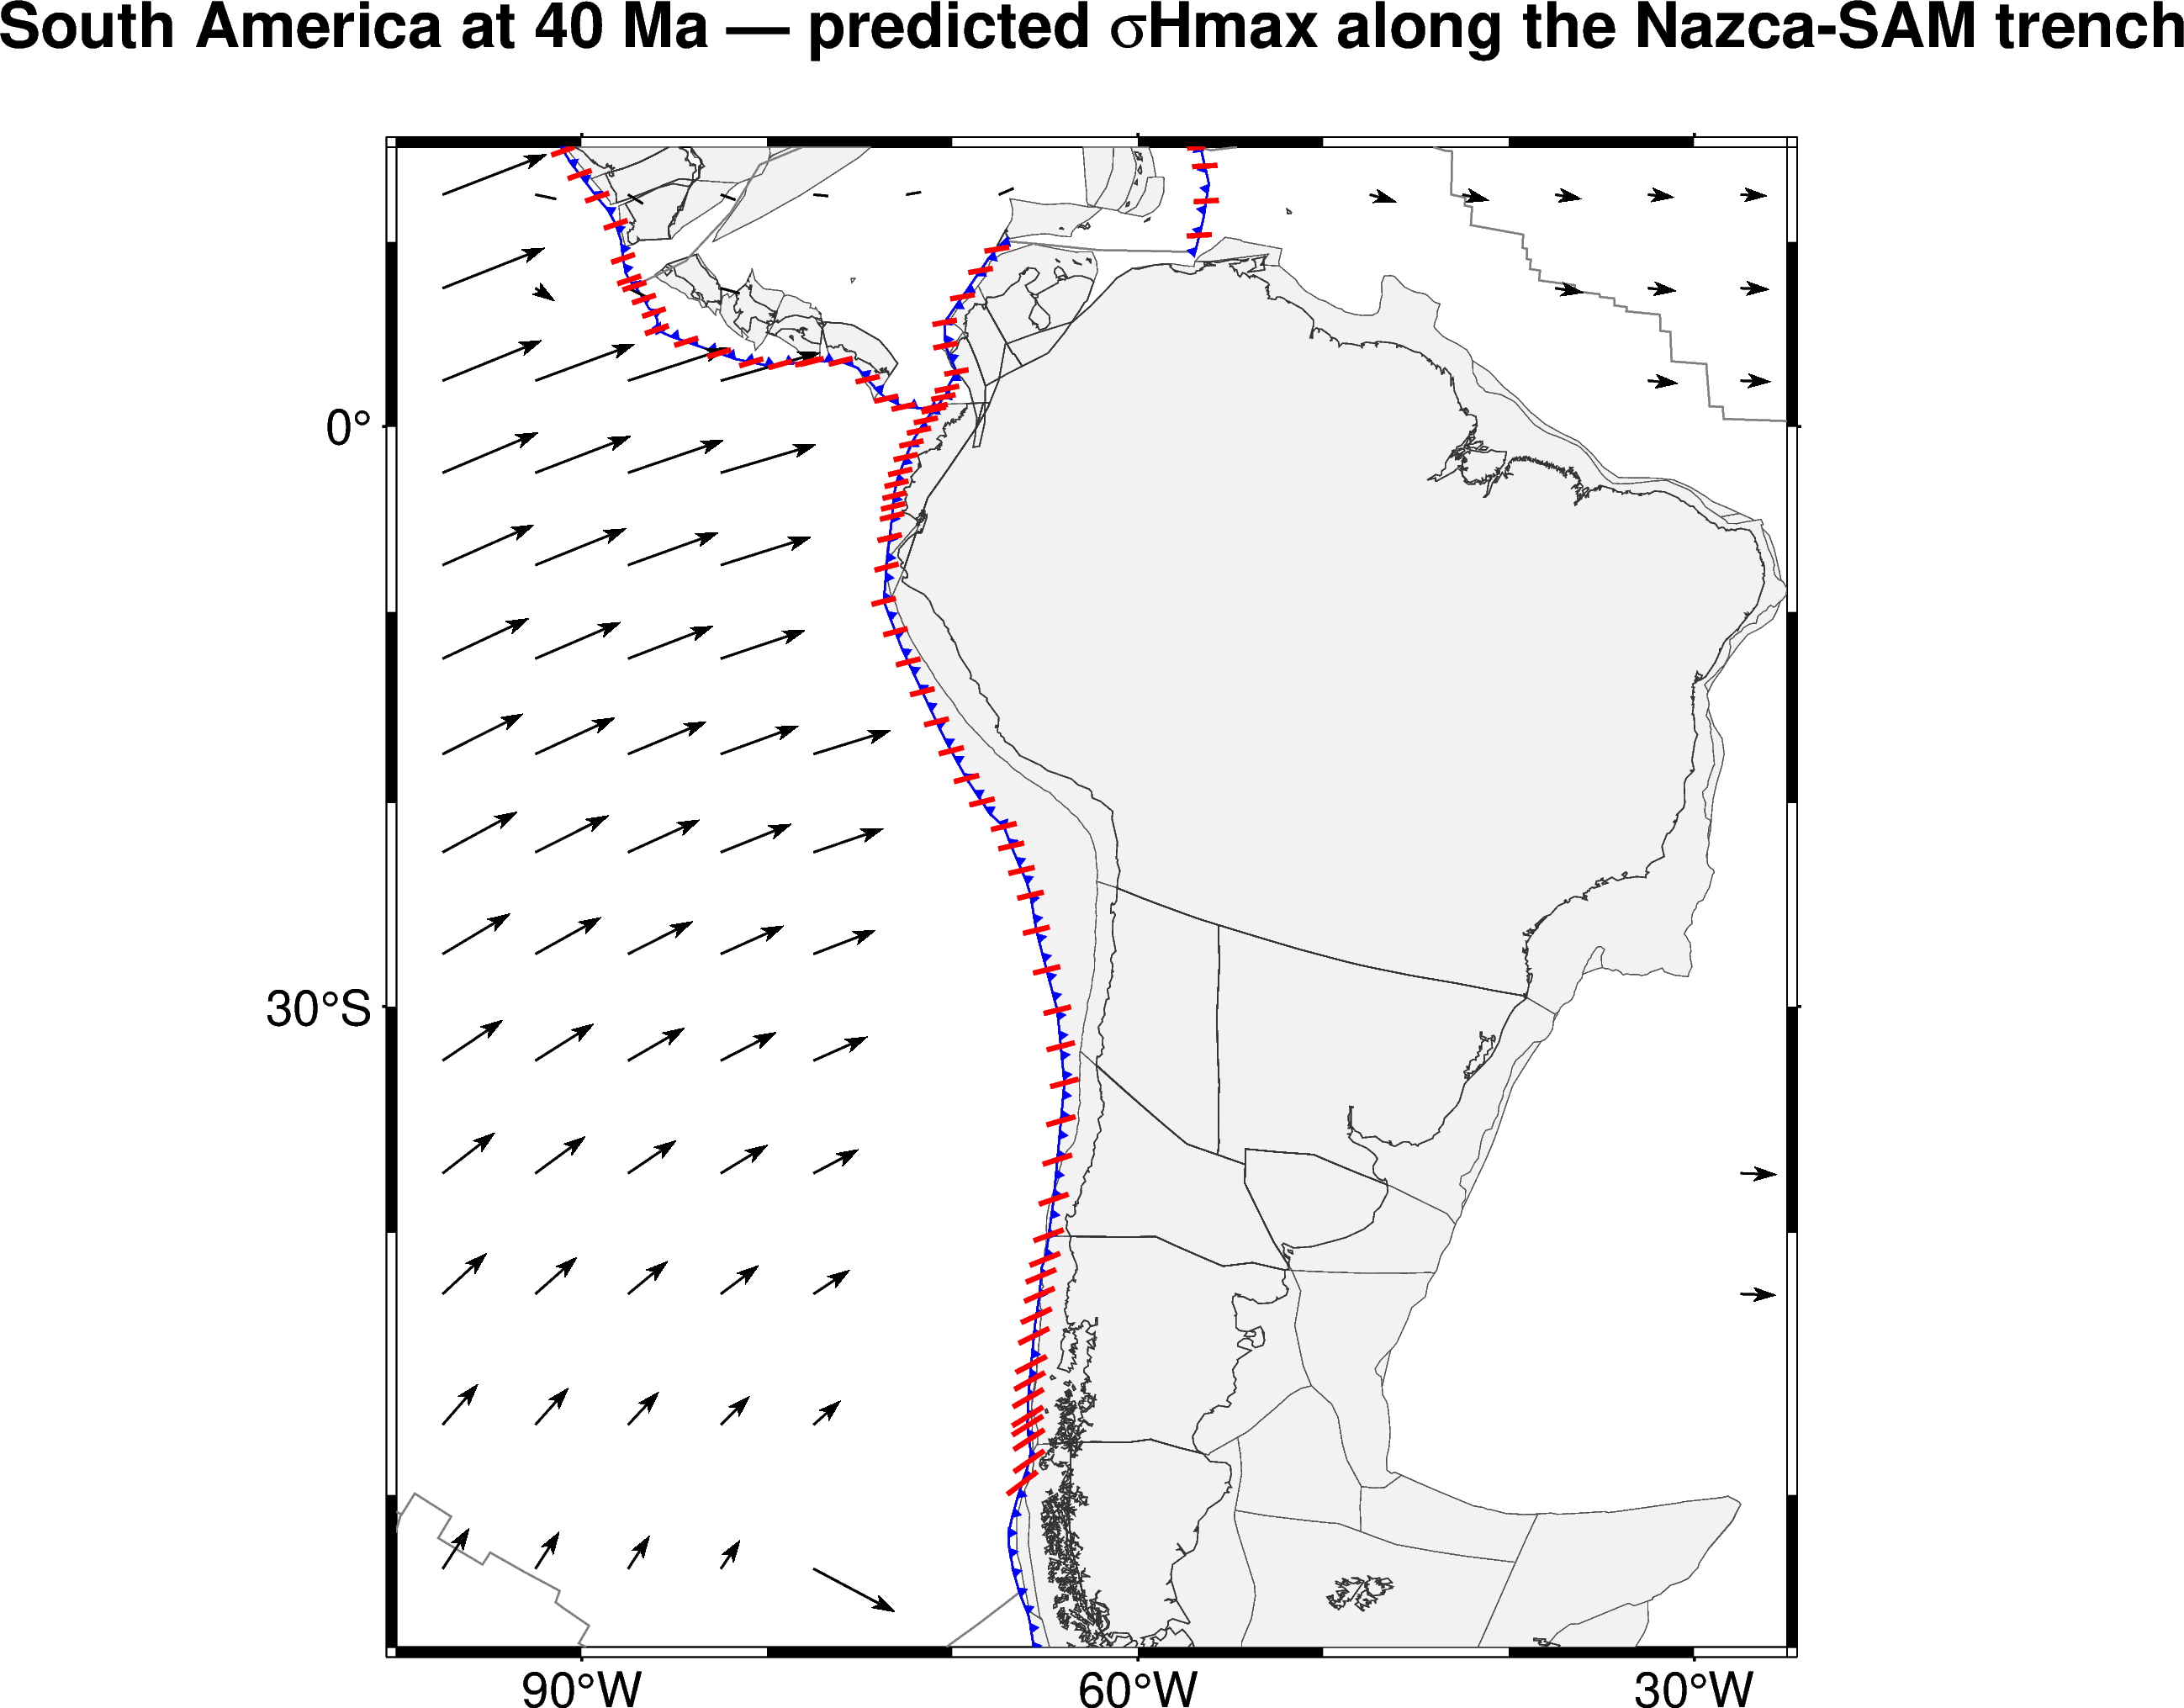

In [8]:
# Render at 40 Ma
fig = pygmt.Figure()
draw_panel(fig, 40,
           system_label="South America",
           region=SAM_REGION,
           results_dict=results,
           wsm_binned_obs=wsm_binned,
           delta_median_val=delta_median)
import os
os.makedirs('outputs', exist_ok=True)
fig.savefig('outputs/T15_Andean_sHmax_040Ma.png', dpi=300)
print('saved outputs/T15_Andean_sHmax_040Ma.png')
fig.show(width=750)
display(HTML('<div style="height:1cm"></div>'))   # 1 cm gap before next figure

### 5c. South America at present day — comparison with WSM 2025

The validation panel. **Red bars** are the predicted first-order σHmax (same recipe as above, with the 0-Ma SAM-Nazca stage pole). **Dark-cyan bars** are observations from the World Stress Map 2025: the A/B/C-quality records inside the SAM-margin box, binned to 2°×2° cells with circular-mean azimuth, then trimmed to cells within 4° of a predicted trench point. The panel title reports the **median absolute difference (Δ)** — the median absolute difference between each binned observation and the nearest predicted-trench σHmax, computed modulo 180°. We display it as `median Δ = X°` on the panel title. A low number (≲ 25°) means the simple first-order plate-pair model captures the modern Andean forearc stress field reasonably well.

**What to look for.** Where red and dark-cyan bars align, the prediction is succeeding (the Stephan first-order model is doing its job). Where they disagree — typically the inner forearc and along the Bolivian orocline — the observed stress reflects features the first-order model doesn't attempt to capture: slab geometry, upper-plate microblock rotation, inherited basement fabric, and regional thermal structure.

  t=0 Ma  210 grid points  (0 unassigned)  per-plate {802: 14, 201: 132, 911: 41, 909: 8, 701: 7, 224: 8}  fastest: (-87.5°E,2.5°N) plate=909 east=+7.74 north=+6.47 speed=10.09 cm/yr
  arrows @ 0 Ma: 210 grid points, 78 drawn (speed >= 0.05 cm/yr), 132 suppressed near SA, max speed 10.09 cm/yr
saved outputs/T15_Andean_sHmax_000Ma_with_WSM.png


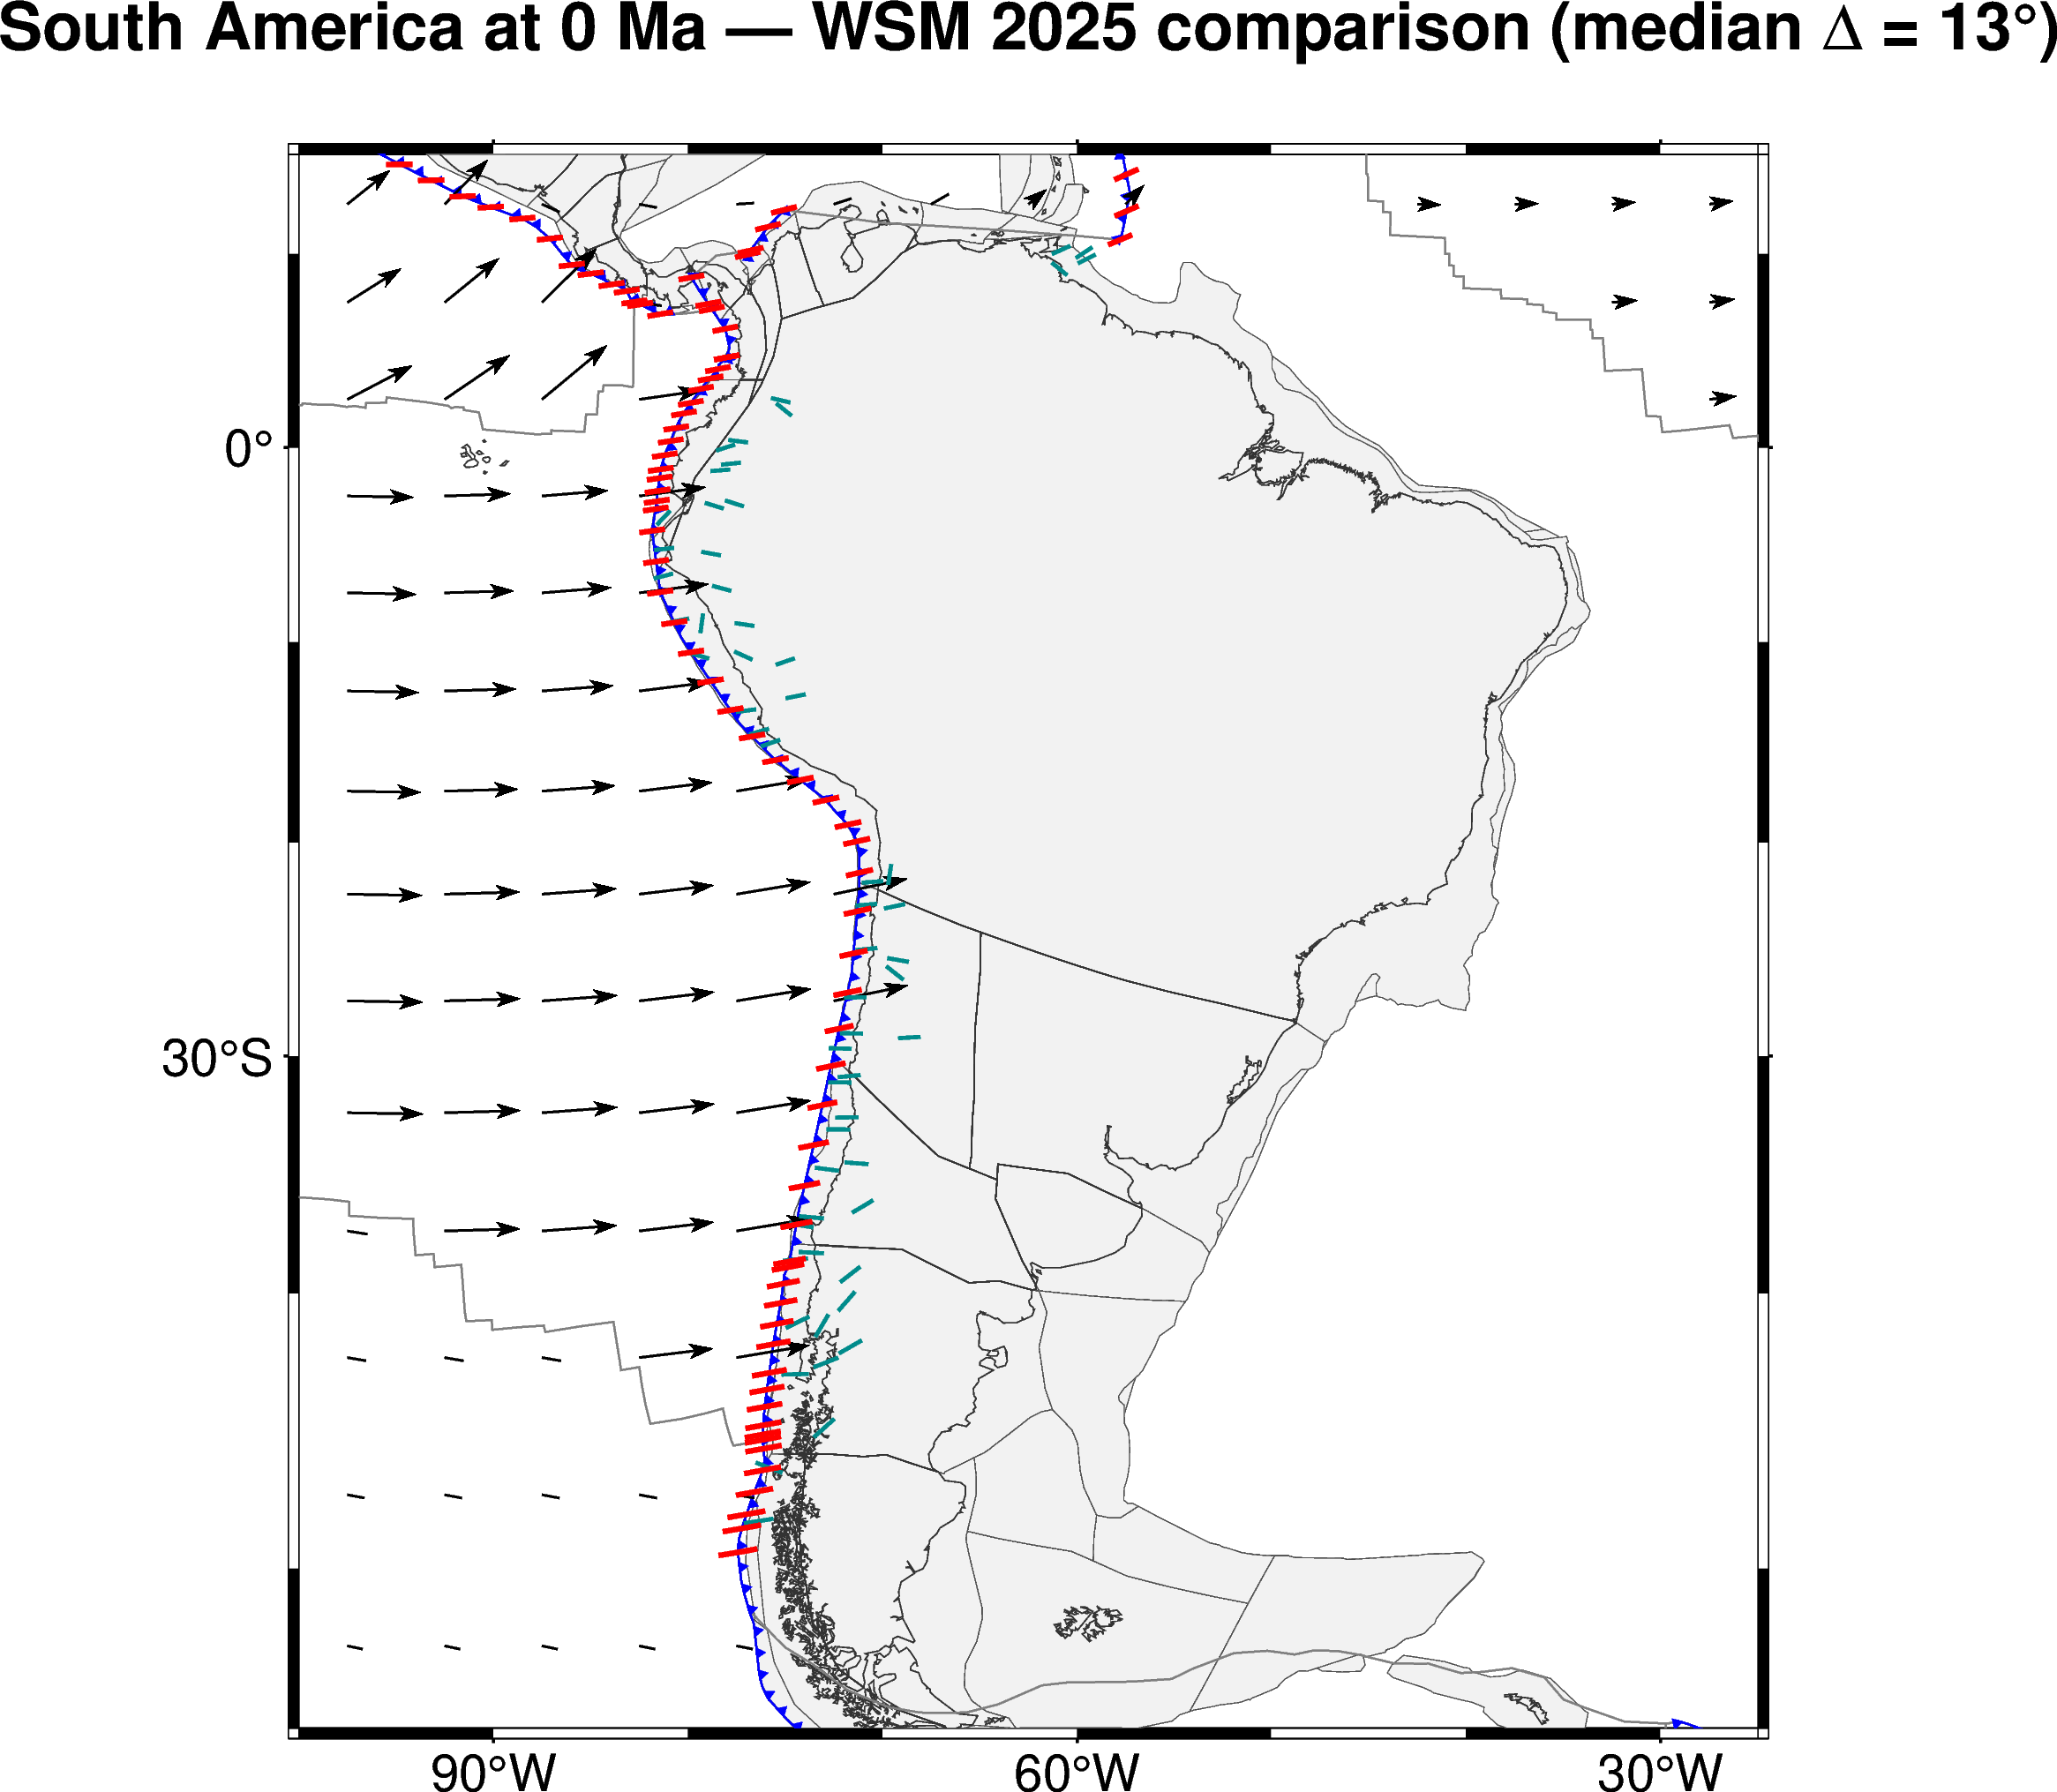

In [9]:
# Render at 0 Ma — with WSM 2025 observed bars overlaid
fig = pygmt.Figure()
draw_panel(fig, 0,
           system_label="South America",
           region=SAM_REGION,
           results_dict=results,
           wsm_binned_obs=wsm_binned,
           delta_median_val=delta_median)
import os
os.makedirs('outputs', exist_ok=True)
fig.savefig('outputs/T15_Andean_sHmax_000Ma_with_WSM.png', dpi=300)
print('saved outputs/T15_Andean_sHmax_000Ma_with_WSM.png')
fig.show(width=750)
display(HTML('<div style="height:1cm"></div>'))   # 1 cm gap before next figure

## 6. What the maps tell us

The three panels are a tour through the Cenozoic life of the Andean margin. The predicted σHmax stays close to trench-perpendicular at both 40 Ma and 0 Ma because the Nazca-SAM relative-motion pole does not change dramatically through the late Cenozoic. The 0-Ma panel adds the observed WSM 2025 σHmax field: median agreement is within ≈20°, which is the first-order success that Stephan et al. (2023) reported globally.

Where the model misfits the observations — typically the inner forearc and the Bolivian orocline — is exactly where second-order processes take over from the first-order Euler-pole prediction (microplate rotation, slab-geometry change, inherited basement). This is the lower bound on the predictive skill of a single-pole first-order model.

The plate-motion arrows in the SA-fixed reference frame make the link between far-field kinematics and the σHmax bars visible at a glance. The arc-perpendicular σHmax orientation at any point along the trench is essentially the azimuth of the Nazca convergence arrow at that latitude — wherever the Nazca arrows rotate (e.g. around the Bolivian orocline, or near the Chile triple junction), the σHmax bars rotate with them. Picking SA as the anchor isolates the *relative*-motion field that drives the boundary forcing; if you re-anchored to plate 0 (the hotspot frame) instead, every arrow would carry an extra ~3–4 cm yr⁻¹ of hotspot-frame motion that distracts from the boundary signal. The anchor plate is set via the `anchor_plate_id` argument of `calculate_sa_fixed_motion_arrows` in cell 6a — change it to e.g. 901 (Pacific) or 0 (no-net-rotation) to see how the *appearance* of the kinematic field depends on the chosen reference frame even though the *trench-normal convergence* (and hence the σHmax field) does not.

## Extend this

- **Other margins.** Swap `SAM_MARGIN_BOX`, `SAM_PLATE_ID`, and `NAZ_PLATE_ID` for the Cascadia, Tonga–Kermadec, or central-Aleutian subduction zones. Each case will tell you something different about how the first-order model behaves at a margin with a different convergence obliquity.
- **Animate through deep time.** Run for `t in range(0, 41, 2)` and stitch the frames into an MP4. Combined with the recipe in **T03**, you get a movie of the predicted σHmax evolution along the Andean margin.
- **Norm χ² goodness-of-fit.** Replace the median-IQR Δ with the quality-weighted Norm χ² defined in Eq. 15 of Stephan et al. 2023.
- **Cross-reference with T14.** T14 computes the deforming-mesh dilatation rate and per-vertex velocities. Rendering those for the SAM region would highlight where the observed extension is concentrated — useful context for any inner-forearc misfit you see in the 0-Ma panel above.
- **Cross-reference with T11.** If predicted σHmax is directed inland at past times, sediment shed from the orogen would have routed accordingly. Combined with T11's detrital-zircon source-to-sink mapping you can test the implied paleo-drainage.

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371-383. https://doi.org/10.1002/gdj3.146
- Stephan, T., Enkelmann, E. & Kroner, U. (2023). Estimating horizontal stress from earthquake focal mechanisms with applications to plate-boundary-related stress. *Scientific Reports* 13, 15590. https://doi.org/10.1038/s41598-023-42433-2
- Heidbach, O., Rajabi, M., Cui, X., Fuchs, K., Müller, B., Reinecker, J., Reiter, K., Tingay, M., Wenzel, F., Xie, F., Ziegler, M.O., Zoback, M.L. & Zoback, M. (2018). The World Stress Map database release 2016: Crustal stress pattern across scales. *Tectonophysics* 744, 484-498. https://doi.org/10.1016/j.tecto.2018.07.007
- Zoback, M.L. (1992). First- and second-order patterns of stress in the lithosphere: The World Stress Map Project. *J. Geophys. Res. Solid Earth* 97, 11703-11728. https://doi.org/10.1029/92JB00132